In [1]:
from dataset_registery.registery import DatasetManager
from frameworks.LightenDiffusion.models.decom import ImageEncoder, ImageDecoder, RetinexDecomposition
from frameworks.LightenDiffusion.models.LightenDiffusion import Stage1, Stage2, LightenDiffusionPipeline
from frameworks.LightenDiffusion.models.unet import DiffusionUNet
from eda.helpers.data_helpers import split_dataloader
from frameworks.LightenDiffusion.visualization.visualize_stage2 import visualize_stage2_results, visualize_restorations
from evaluation.lighten_diffusion_stage2 import evaluate_stage2_metrics_avgfirst
import os
import torch
import pandas as pd
from IPython.display import display
import sys
sys.path.append("/scratch/user/u.ok285885/LightenDiffusion")
from models import DenoisingDiffusion, DiffusiveRestoration
from metrics_eval import evaluate_loader
from types import SimpleNamespace
from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader
import torch.nn as nn
import utils
%load_ext autoreload
%autoreload 2

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /scratch/user/u.ok285885/lle-generative-priors/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


In [2]:
data_name = "SICE_paired"
dataset_id = "okhater/SICE"
source = "huggingface"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_VISUALIZATION_SAMPLES = 4
print(f"Device used : {device}")

Device used : cuda


In [3]:
registry = DatasetManager()
registry.initialize_dataset(
    name=data_name,
    dataset_id=dataset_id,
    splits=["train", "test"],
    dataset_type="paired",
    hf_cache_dir=f"../../datasets/{data_name}",
)

train_loader = registry.get_dataloader(data_name, "train", batch_size=16, shuffle=True)
test_loader = registry.get_dataloader(data_name, "test", batch_size=16, shuffle=True)
train_loader, val_loader = split_dataloader(train_loader, split_ratio=0.2)

loaders = {
    "train": train_loader, 
    "val": val_loader, 
    "test": test_loader
    }
for name, loader in loaders.items():
    total_samples = len(loader.dataset)
    print(f"Loader: {name}, Total samples: {total_samples}")
    for low_imgs, label in loader:
        print(f"Batch contains {len(low_imgs)} low image samples.")
        print("Low images batch shape:", low_imgs.shape)
        print("Label batch shape:", label.shape)
        break
    print("==="*20)

Resolving data files:   0%|          | 0/1280 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/223 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1280 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/223 [00:00<?, ?it/s]

Loader: train, Total samples: 207
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])
Loader: val, Total samples: 51
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])
Loader: test, Total samples: 46
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])


In [4]:
class PipelineWrapper(nn.Module):
    def __init__(self, restorer):
        super().__init__()
        self.restorer = restorer
    def predict(self, low_imgs):
        # low_imgs: [B, m, 3, H, W]
        return self.restorer.forward_sample(
            low_imgs.view(low_imgs.size(0), -1, low_imgs.size(-2), low_imgs.size(-1))
        )

In [5]:
# ── 1) ARGS ───────────────────────────────────────────────────────────────
#   • `resume` is where your Stage-2 checkpoint lives
#   • `mode="training"` triggers Net.load_stage1(...) so we load CTDN
#   • `paired` tells evaluate_loader that x/y come in pairs
args = SimpleNamespace(
    resume = "/scratch/user/u.ok285885/LightenDiffusion/ckpt/stage2/stage2_weight.pth.tar",
    mode   = "training",
    stage1_path = "/scratch/user/u.ok285885/LightenDiffusion/ckpt/stage1",
    paired = True,
    image_folder  = "./paper_model_results",
)

# ── 2) CONFIG ─────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#   2a) Data sub-config only needs `.conditional` for UNet in-channels
data_cfg = SimpleNamespace(
    conditional = True,
    val_dataset = 'SICE300'
)

#   2b) Model sub-config must match how you trained your UNet
model_cfg = SimpleNamespace(
    in_channels      = 3,
    out_ch           = 3,
    ch               = 64,
    ch_mult          = [1, 2, 3, 4],
    num_res_blocks   = 2,
    dropout          = 0.0,
    resamp_with_conv = True,
)

#   2c) Diffusion hyperparameters (must match your training schedule)
diff_cfg = SimpleNamespace(
    beta_schedule           = "linear",
    beta_start              = 0.0001,
    beta_end                = 0.02,
    num_diffusion_timesteps = 1000,
    num_sampling_timesteps  = 20,
)

optim_cfg = SimpleNamespace(
    optimizer    = "Adam",
    lr           = 0.00002,
    weight_decay = 0.0,
    amsgrad      = False,
    eps          = 1e-8,
)

config = SimpleNamespace(
    device    = device,
    data      = data_cfg,
    model     = model_cfg,
    diffusion = diff_cfg,
    optim     = optim_cfg,
)



In [6]:
diffusion         = DenoisingDiffusion(args, config)
restoration_model = DiffusiveRestoration(diffusion, args, config)
model = PipelineWrapper(restoration_model)


=> loaded checkpoint /scratch/user/u.ok285885/LightenDiffusion/ckpt/stage2/stage2_weight.pth.tar step 0


In [7]:
metrics_train_AF = evaluate_stage2_metrics_avgfirst(model,train_loader)

Evaluating Stage2 (Average-First): 100%|██████████| 13/13 [02:23<00:00, 11.03s/it]


In [8]:
metrics_test_AF = evaluate_stage2_metrics_avgfirst(model,test_loader)

Evaluating Stage2 (Average-First): 100%|██████████| 3/3 [00:33<00:00, 11.03s/it]


In [9]:
results_df = pd.DataFrame({
    "train_Average_First": metrics_train_AF,
    "test_Average_First": metrics_test_AF,
})
display(results_df)

,train_Average_First,test_Average_First
psnr,16.280040,16.672969
ssim,0.701360,0.657544
lpips,0.269023,0.288716
niqe,4.838788,4.997894
pi,2.553906,2.643305


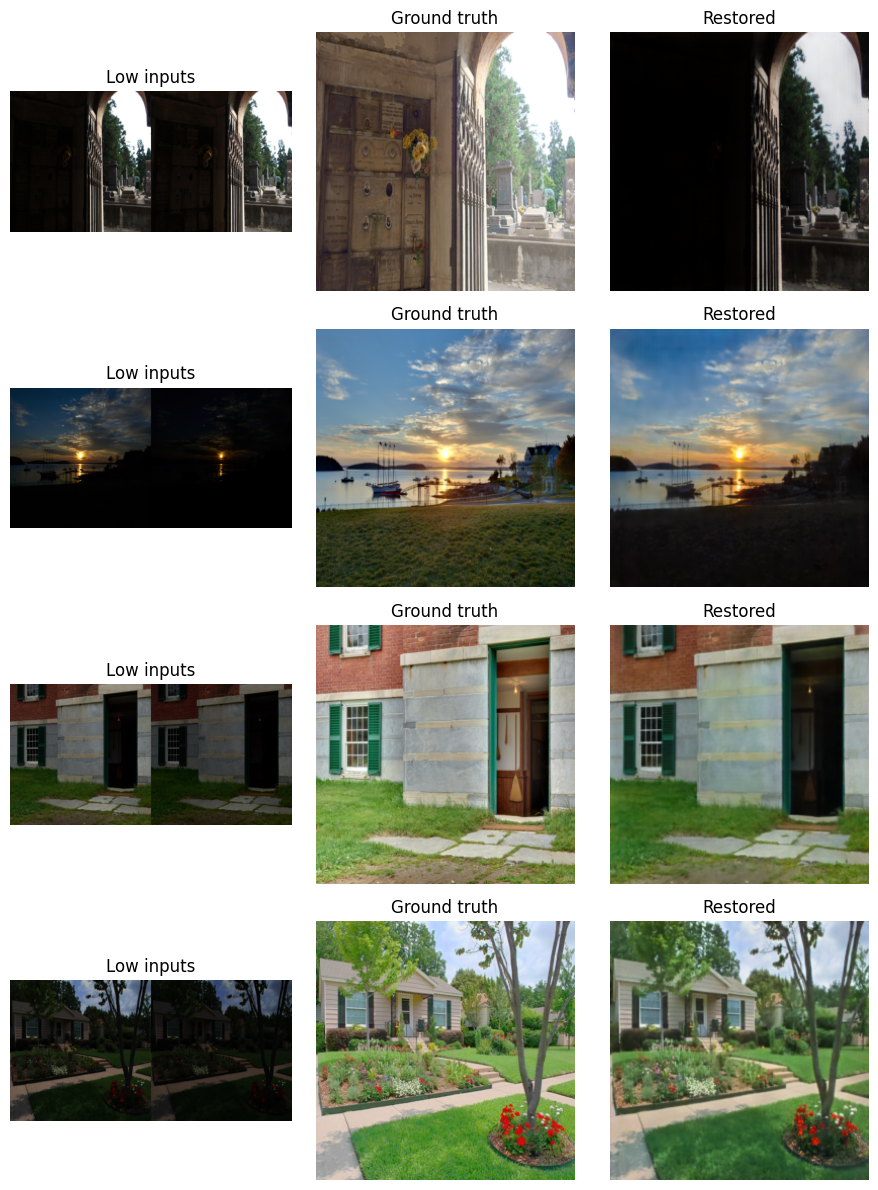

In [10]:
visualize_restorations(
    restorer=restoration_model,
    data_loader=train_loader,      
    device=device,
    num_samples=4,
    save_dir=None
)

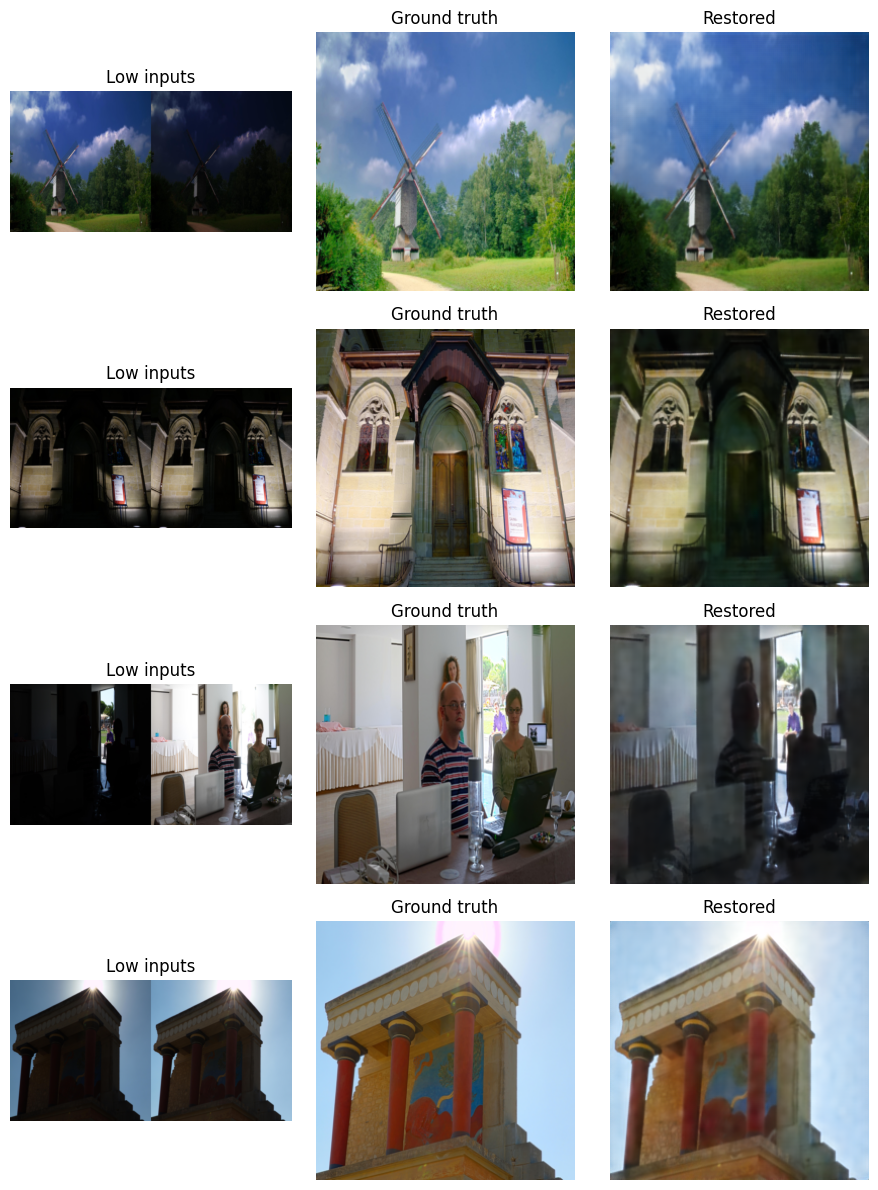

In [11]:
visualize_restorations(
    restorer=restoration_model,    
    data_loader=test_loader,     
    device=device,
    num_samples=4,
    save_dir=None
)